In [1]:
import joblib

# Load the model
attention_model = joblib.load("../models/test1/attention_model.pkl")

In [2]:
import numpy as np
import tensorflow as tf

def mc_dropout_predict(model, X, n_iter=100):
    """
    Monte Carlo Dropout Prediction

    Parameters
    ----------
    model : trained keras model
    X : input features
    n_iter : number of stochastic forward passes

    Returns
    -------
    mean_prob : Mean predicted probability
    std_prob : Standard deviation (uncertainty)
    predictions : All predictions
    """

    X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

    predictions = []

    for _ in range(n_iter):
        pred = model(X_tensor, training=True).numpy().flatten()
        predictions.append(pred)

    predictions = np.array(predictions)

    mean_prob = predictions.mean(axis=0)
    std_prob = predictions.std(axis=0)

    return mean_prob, std_prob, predictions

In [7]:
import pandas as pd
X_train = pd.read_csv('../data/processed/X_train_smote.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train_smote.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train.drop(columns=['Satisfaction Score'], inplace=True)
X_test.drop(columns=['Satisfaction Score'], inplace=True)
X_train_nn = scaler.fit_transform(X_train)
X_test_nn = scaler.transform(X_test)



In [8]:
mean_prob, std_prob, all_predictions = mc_dropout_predict(
    attention_model,
    X_test_nn,
    n_iter=100
)

In [9]:
print(mean_prob[:10])
print(std_prob[:10])

[1.5244302e-02 7.4977521e-03 7.0266515e-02 6.5626218e-03 9.0178230e-04
 5.2893740e-01 9.1379935e-01 8.4573174e-01 4.6775091e-01 9.3719614e-01]
[0.06455908 0.03153379 0.09947506 0.03312453 0.00480469 0.15785125
 0.08489642 0.11466307 0.12888996 0.088544  ]


In [10]:
pred_class = (mean_prob >= 0.5).astype(int)

In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

print(classification_report(y_test, pred_class))

print(confusion_matrix(y_test, pred_class))

print("Accuracy :", accuracy_score(y_test, pred_class))
print("Precision:", precision_score(y_test, pred_class))
print("Recall   :", recall_score(y_test, pred_class))
print("F1       :", f1_score(y_test, pred_class))
print("ROC AUC  :", roc_auc_score(y_test, mean_prob))
print("PR AUC   :", average_precision_score(y_test, mean_prob))
print("MCC      :", matthews_corrcoef(y_test, pred_class))

              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1035
           1       0.61      0.82      0.70       374

    accuracy                           0.81      1409
   macro avg       0.77      0.81      0.78      1409
weighted avg       0.84      0.81      0.82      1409

[[834 201]
 [ 66 308]]
Accuracy : 0.8105039034776437
Precision: 0.6051080550098232
Recall   : 0.8235294117647058
F1       : 0.6976217440543602
ROC AUC  : 0.8885246325144025
PR AUC   : 0.7264414332991844
MCC      : 0.5784979960276446


In [21]:


print(type(pred_class), pred_class.shape)

print(type(mean_prob), mean_prob.shape)

print(type(std_prob), std_prob.shape)

y_test_values = y_test.squeeze().values

print(type(y_test_values), y_test_values.shape)

<class 'numpy.ndarray'> (1409,)
<class 'numpy.ndarray'> (1409,)
<class 'numpy.ndarray'> (1409,)
<class 'numpy.ndarray'> (1409,)


In [22]:
import pandas as pd

uncertainty_df = pd.DataFrame({
    "True_Label": y_test_values,
    "Prediction": pred_class,
    "Probability": mean_prob,
    "Uncertainty": std_prob
})

uncertainty_df.head()

,True_Label,Prediction,Probability,Uncertainty
0,0,0,0.015244,0.064559
1,0,0,0.007498,0.031534
2,0,0,0.070267,0.099475
3,0,0,0.006563,0.033125
4,0,0,0.000902,0.004805


In [23]:
uncertainty_df.sort_values(
    by="Uncertainty",
    ascending=False
).head(20)

,True_Label,Prediction,Probability,Uncertainty
662,0,0,0.392512,0.344367
1078,1,1,0.560759,0.300227
1177,0,1,0.635441,0.263888
107,0,0,0.426406,0.251981
959,0,0,0.216579,0.232707
998,0,0,0.314105,0.223969
590,0,1,0.606528,0.221484
1250,1,1,0.615529,0.220855
393,0,1,0.531847,0.217757
425,0,0,0.376460,0.214252


In [24]:
print(uncertainty_df["Uncertainty"].describe())

count    1409.000000
mean        0.081009
std         0.045299
min         0.000358
25%         0.045124
50%         0.083267
75%         0.109109
max         0.344367
Name: Uncertainty, dtype: float64


In [25]:
q1 = uncertainty_df["Uncertainty"].quantile(0.25)
q3 = uncertainty_df["Uncertainty"].quantile(0.75)

def confidence_level(u):
    if u <= q1:
        return "High Confidence"
    elif u <= q3:
        return "Medium Confidence"
    else:
        return "Low Confidence"

uncertainty_df["Confidence_Level"] = (
    uncertainty_df["Uncertainty"]
    .apply(confidence_level)
)

print(uncertainty_df["Confidence_Level"].value_counts())

Confidence_Level
Medium Confidence    704
High Confidence      353
Low Confidence       352
Name: count, dtype: int64


In [26]:
import numpy as np

epsilon = 1e-10

uncertainty_df["Entropy"] = -(
    uncertainty_df["Probability"] * np.log(uncertainty_df["Probability"] + epsilon)
    +
    (1 - uncertainty_df["Probability"]) *
    np.log(1 - uncertainty_df["Probability"] + epsilon)
)

uncertainty_df.head()

,True_Label,Prediction,Probability,Uncertainty,Confidence_Level,Entropy
0,0,0,0.015244,0.064559,Medium Confidence,0.078903
1,0,0,0.007498,0.031534,High Confidence,0.044157
2,0,0,0.070267,0.099475,Medium Confidence,0.254328
3,0,0,0.006563,0.033125,High Confidence,0.039527
4,0,0,0.000902,0.004805,High Confidence,0.007224


In [27]:
print(uncertainty_df[["Probability", "Uncertainty", "Entropy"]].describe())

       Probability  Uncertainty      Entropy
count  1409.000000  1409.000000  1409.000000
mean      0.361499     0.081009     0.301908
std       0.371141     0.045299     0.228266
min       0.000060     0.000358     0.000648
25%       0.020304     0.045124     0.093605
50%       0.177076     0.083267     0.242966
75%       0.760452     0.109109     0.514706
max       0.993091     0.344367     0.693147


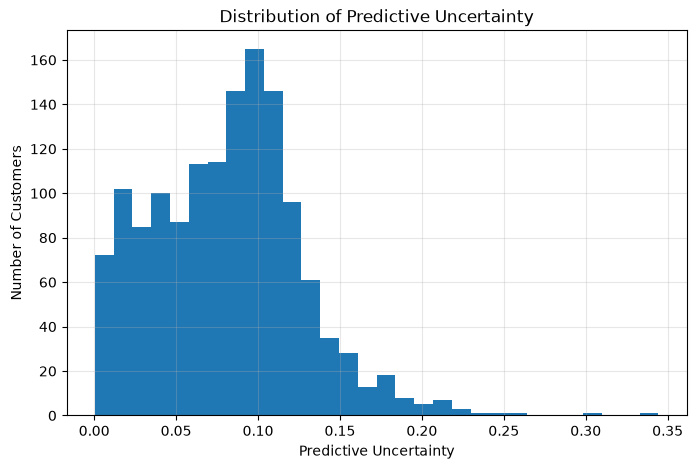

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    uncertainty_df["Uncertainty"],
    bins=30
)

plt.xlabel("Predictive Uncertainty")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predictive Uncertainty")

plt.grid(alpha=0.3)

plt.show()

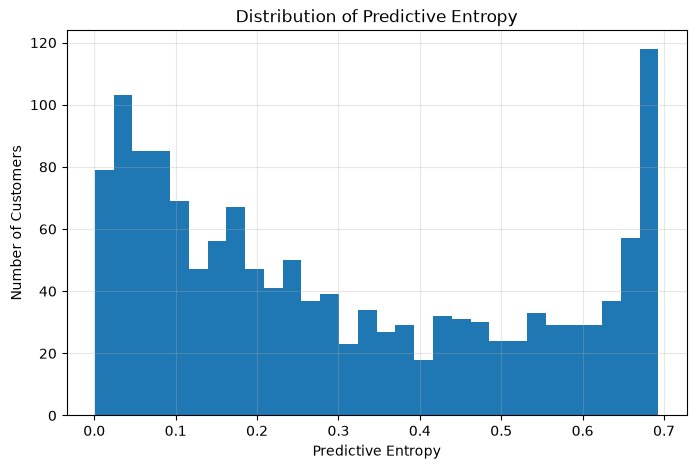

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    uncertainty_df["Entropy"],
    bins=30
)

plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predictive Entropy")

plt.grid(alpha=0.3)

plt.show()

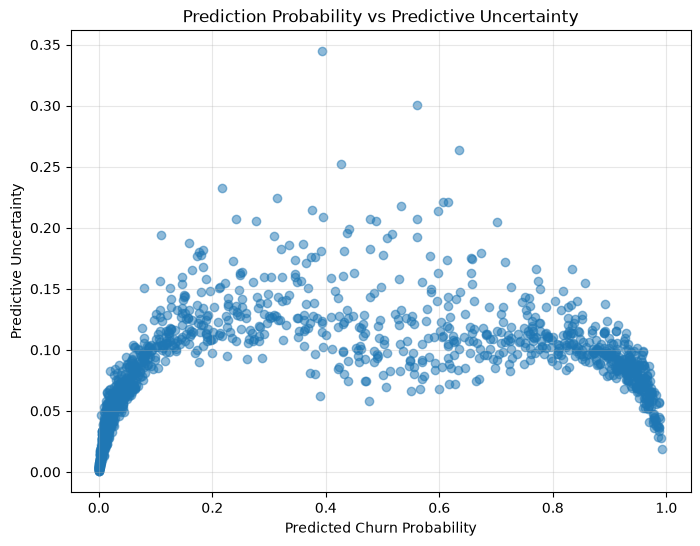

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    uncertainty_df["Probability"],
    uncertainty_df["Uncertainty"],
    alpha=0.5
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Predictive Uncertainty")

plt.title("Prediction Probability vs Predictive Uncertainty")

plt.grid(alpha=0.3)

plt.show()

In [31]:
uncertainty_df["Correct"] = (
    uncertainty_df["True_Label"] ==
    uncertainty_df["Prediction"]
)

In [32]:
print(
    uncertainty_df.groupby("Correct")["Uncertainty"].mean()
)

Correct
False    0.109588
True     0.074327
Name: Uncertainty, dtype: float32


<Figure size 700x500 with 0 Axes>

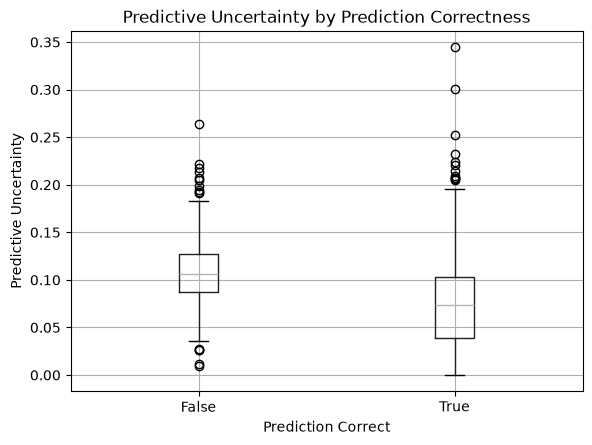

In [33]:
plt.figure(figsize=(7,5))

uncertainty_df.boxplot(
    column="Uncertainty",
    by="Correct"
)

plt.title("Predictive Uncertainty by Prediction Correctness")
plt.suptitle("")

plt.xlabel("Prediction Correct")
plt.ylabel("Predictive Uncertainty")

plt.show()

In [34]:
from scipy.stats import mannwhitneyu

correct_uncertainty = uncertainty_df.loc[
    uncertainty_df["Correct"], "Uncertainty"
]

incorrect_uncertainty = uncertainty_df.loc[
    ~uncertainty_df["Correct"], "Uncertainty"
]

stat, p = mannwhitneyu(
    correct_uncertainty,
    incorrect_uncertainty,
    alternative="two-sided"
)

print(f"U Statistic: {stat:.2f}")
print(f"P-value: {p:.10f}")

U Statistic: 80292.00
P-value: 0.0000000000


In [36]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test_values, mean_prob)

print(f"Brier Score: {brier:.6f}")

Brier Score: 0.135249


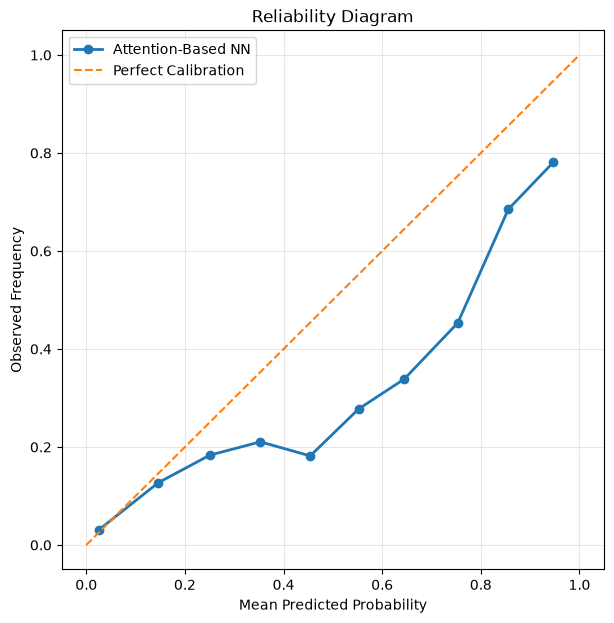

In [38]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

true_prob, pred_prob = calibration_curve(
    y_test_values,
    mean_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7,7))

plt.plot(
    pred_prob,
    true_prob,
    marker='o',
    linewidth=2,
    label="Attention-Based NN"
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")

plt.title("Reliability Diagram")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [40]:
import numpy as np

def expected_calibration_error(y_true, y_prob, n_bins=10):

    bins = np.linspace(0, 1, n_bins + 1)

    binids = np.digitize(y_prob, bins) - 1

    ece = 0

    for i in range(n_bins):

        mask = binids == i

        if np.sum(mask) > 0:

            accuracy = np.mean(y_true[mask])

            confidence = np.mean(y_prob[mask])

            ece += (
                np.sum(mask) / len(y_true)
            ) * abs(accuracy - confidence)

    return ece

ece = expected_calibration_error(y_test_values, mean_prob)

print(f"Expected Calibration Error (ECE): {ece:.6f}")

Expected Calibration Error (ECE): 0.100923


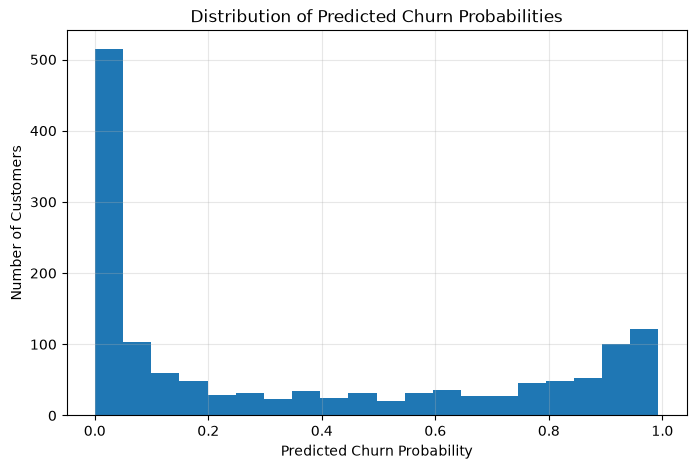

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    mean_prob,
    bins=20
)

plt.xlabel("Predicted Churn Probability")

plt.ylabel("Number of Customers")

plt.title("Distribution of Predicted Churn Probabilities")

plt.grid(alpha=0.3)

plt.show()

<Figure size 700x500 with 0 Axes>

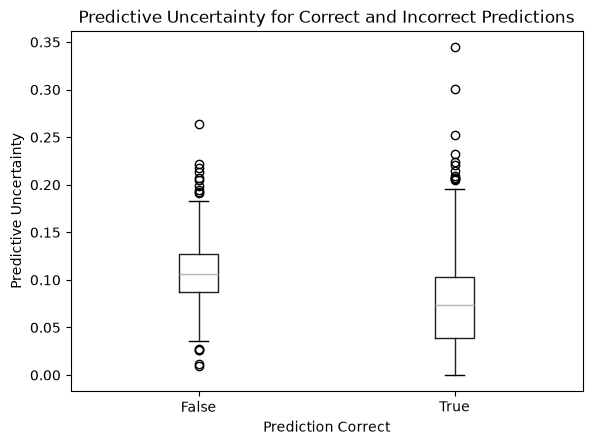

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

uncertainty_df.boxplot(
    column="Uncertainty",
    by="Correct",
    grid=False
)

plt.title("Predictive Uncertainty for Correct and Incorrect Predictions")
plt.suptitle("")

plt.xlabel("Prediction Correct")
plt.ylabel("Predictive Uncertainty")

plt.show()